## 02 - Pré-processamento de Dados

In [24]:
# Manipulação de dados
import pandas as pd 
import numpy as np 

# Visualização
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

# Serialização de objetos (salvar/carregar modelos/pipelines)
import joblib

# Construção de pipelines e transformadores
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.impute import SimpleImputer

# Logging (silencia mensagens não críticas)
import logging
logging.getLogger().setLevel(logging.CRITICAL)


### Leitura dos dados de treinamento

In [25]:
df_train = pd.read_csv('./Data/train.csv')
X_train = df_train.drop(columns=['MEDV'])
y_train = df_train['MEDV']

In [26]:
df_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,5.69175,0.0,18.10,0.0,0.583,6.114,79.8,3.5459,24,666,20.2,392.68,14.98,19.1
1,0.07013,0.0,13.89,0.0,0.550,6.642,85.1,3.4211,5,276,16.4,392.78,9.69,28.7
2,15.02340,0.0,18.10,0.0,0.614,5.304,97.3,2.1007,24,666,20.2,349.48,24.91,12.0
3,0.29916,20.0,6.96,0.0,0.464,5.856,42.1,4.4290,3,223,18.6,388.65,13.00,21.1
4,0.24103,0.0,7.38,0.0,0.493,6.083,43.7,5.4159,5,287,19.6,396.90,12.79,22.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,0.11069,0.0,13.89,1.0,0.550,5.951,93.8,2.8893,5,276,16.4,396.90,17.92,21.5
340,0.10469,40.0,6.41,1.0,0.447,7.267,49.0,4.7872,4,254,17.6,389.25,6.05,33.2
341,0.06047,0.0,2.46,0.0,0.488,6.153,68.8,3.2797,3,193,17.8,387.11,13.15,29.6
342,0.78420,0.0,8.14,0.0,0.538,5.990,81.7,4.2579,4,307,21.0,386.75,14.67,17.5


Iniciamos nossa etapa de pré-processamento de Dados com um banco de filtros de variáveis, oganizado da seguinte forma:
- Filtro de Constância: Remove as features que apresentam uma concetração em um unico valor igual ou superior a 70%.
- Filtro de Correlação: Avalia a correlação de Spearman entre pares de features, caso o valor seja maior ou igual a 0.7, removemos a segunda variável do par.
- Filtro Julgamental: Adição ou remoção de features baseadas na precpção do autor

In [27]:
# Função que identifica colunas com alta concentração de valores
# Ex.: Se threshold=0.7, qualquer coluna onde >= 70% dos valores são iguais será marcada.
def Constant_Filter(df, threshold):
    return [
        col for col in df.columns
        if df[col].value_counts(normalize=True).max() >= threshold
    ]

# Lista de colunas que devem ser descartadas (quase constantes)
columns_to_drop = Constant_Filter(X_train, 0.7)

# Lista de colunas que serão mantidas (todas menos as descartadas)
columns_to_keep = X_train.columns.difference(columns_to_drop).tolist()

# Cria novo DataFrame apenas com as colunas úteis (não concentradas)
X_train_filtered_1 = X_train[columns_to_keep]

# Impressão formatada dos resultados
print(140*'-')
print('Removendo as features com alta concentração')
print(140*'-')
print(f'Colunas para descartar: {columns_to_drop}')
print(f'Colunas para manter: {columns_to_keep}')
print(140*'-')


--------------------------------------------------------------------------------------------------------------------------------------------
Removendo as features com alta concentração
--------------------------------------------------------------------------------------------------------------------------------------------
Colunas para descartar: ['ZN', 'CHAS']
Colunas para manter: ['AGE', 'B', 'CRIM', 'DIS', 'INDUS', 'LSTAT', 'NOX', 'PTRATIO', 'RAD', 'RM', 'TAX']
--------------------------------------------------------------------------------------------------------------------------------------------


INDUS DIS 0.7496440865444342
INDUS NOX 0.7844028624724548
INDUS CRIM 0.7234752496500849
DIS INDUS 0.7496440865444342
DIS AGE 0.7716089130328803
CRIM TAX 0.7058899486223869
--------------------------------------------------------------------------------------------------------------------------------------------
Correlation Filter
--------------------------------------------------------------------------------------------------------------------------------------------
Columns to Drop: ['AGE', 'CRIM', 'DIS', 'INDUS', 'NOX', 'TAX']
Columns to Keep: ['RM', 'LSTAT', 'PTRATIO', 'RAD', 'B']
--------------------------------------------------------------------------------------------------------------------------------------------


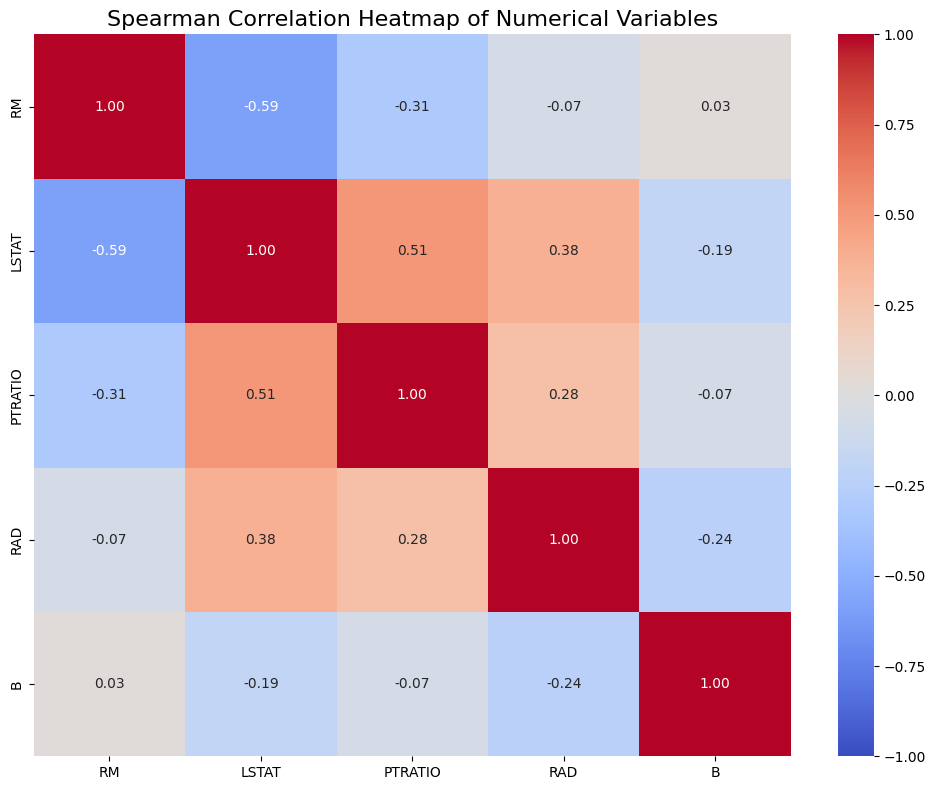

In [28]:
# Função que remove colunas altamente correlacionadas, mantendo apenas uma variável de cada par cuja correlação seja >= threshold
def Correlation_Filter(df, threshold=0.7): 
    # Conjunto inicial de colunas
    cols = set(df.columns)

    # Matriz de correlação de Spearman (mais robusta para monotonicidade)
    cor_mat = df.corr(method='spearman')
    
    # Varre todas as combinações de colunas
    for col1 in list(cols):
        for col2 in list(cols):
            if col1 != col2 and abs(cor_mat.at[col1, col2]) >= threshold:
                # Se a correlação for maior que o limite, remove col2
                print(col1, col2, abs(cor_mat.at[col1, col2]))
                cols.remove(col2)
    # Retorna apenas as colunas que ficaram
    return list(cols)


# Aplica o filtro de correlação no dataset filtrado da etapa anterior
columns_to_keep = Correlation_Filter(X_train_filtered_1, 0.7)

# Colunas que foram eliminadas
columns_to_drop = X_train_filtered_1.columns.difference(columns_to_keep).tolist()

# Novo dataset sem as colunas altamente correlacionadas
X_train_filtered_2 = X_train_filtered_1[columns_to_keep]

# Log do processo
print(140*'-')
print('Correlation Filter')
print(140*'-')
print(f'Columns to Drop: {columns_to_drop}')
print(f'Columns to Keep: {columns_to_keep}')
print(140*'-')


# ----- Visualização -----

# Matriz de correlação final (já sem as variáveis redundantes)
corr_matrix = X_train_filtered_2.corr(method='spearman')

# Plota um heatmap das correlações
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,      # mostra valores dentro dos quadrados
    fmt=".2f",       # 2 casas decimais
    cmap='coolwarm', # cores
    vmin=-1, vmax=1  # range fixo para correlação
)
plt.title('Spearman Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()


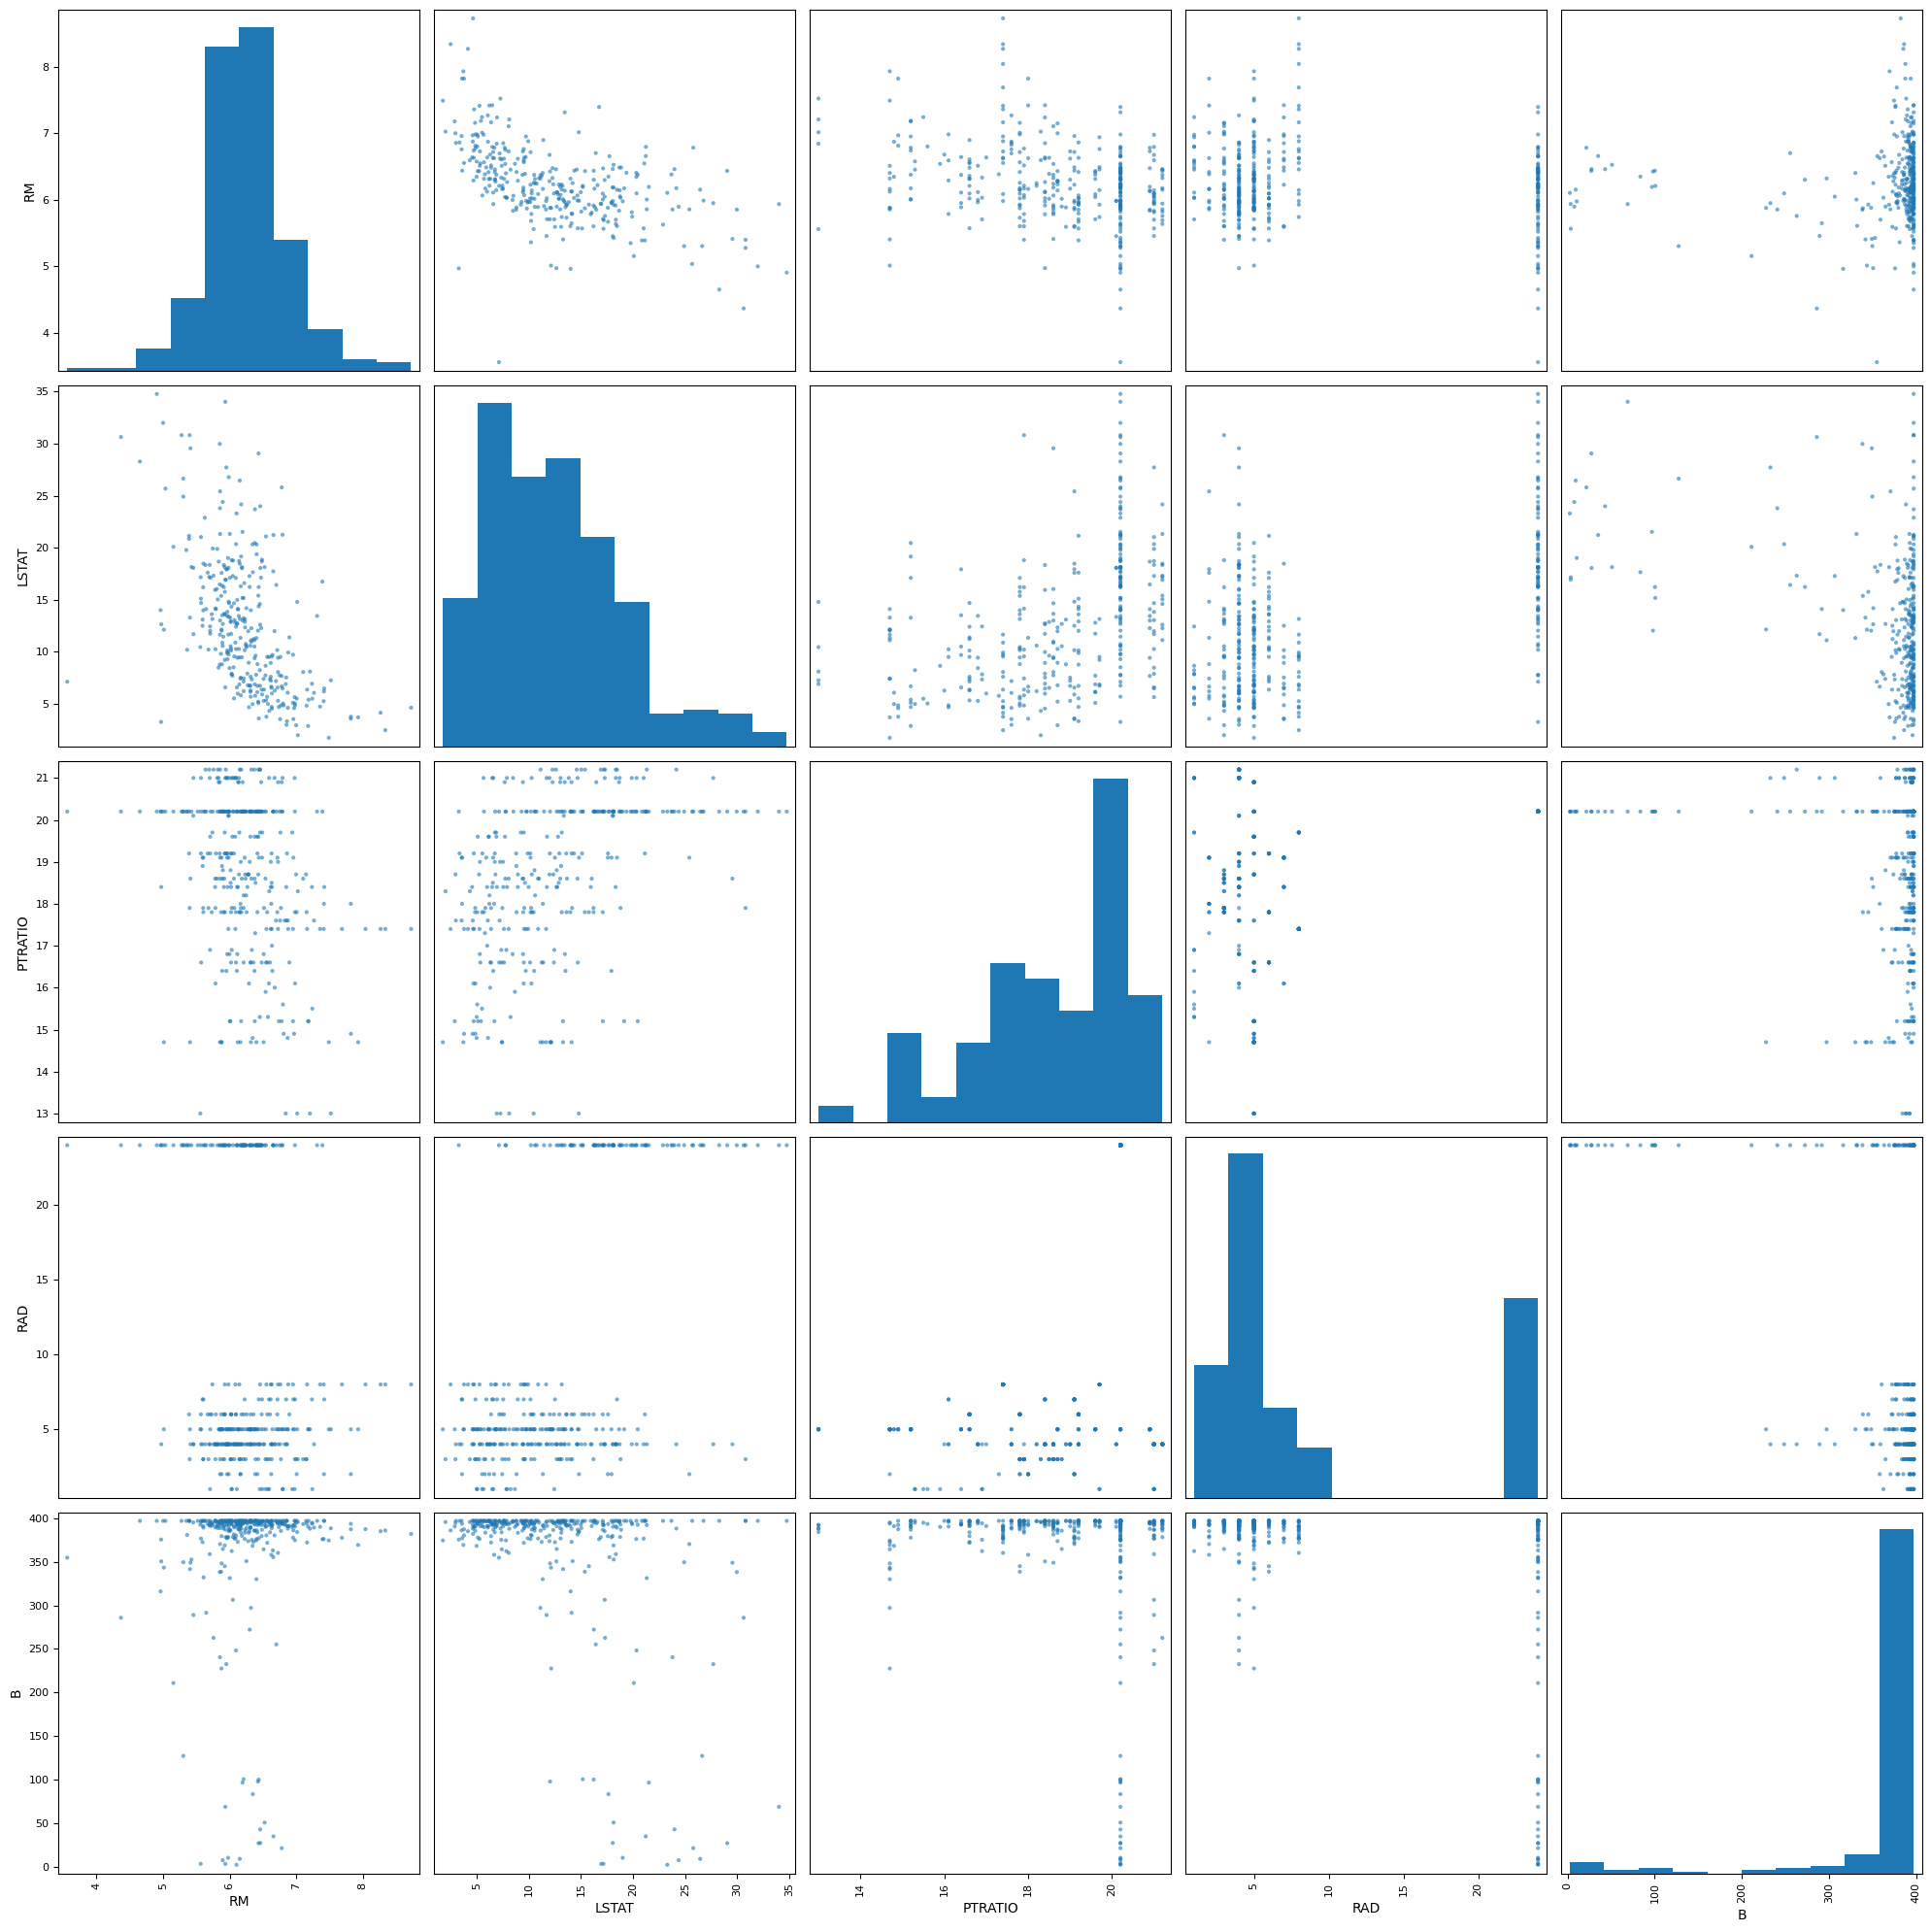

In [29]:
# Cria matriz de dispersão para todas as variáveis em X_train_filtered_2
# figsize define o tamanho total da figura (não precisa passar ax)
fig = pd.plotting.scatter_matrix(
    X_train_filtered_2,
    figsize=(20, 20),  # tamanho da figura
    diagonal='hist',   # histograma na diagonal
    alpha=0.6          # transparência dos pontos
)
plt.tight_layout()
plt.show()


In [30]:
X_train_filtered_2.describe()

,RM,LSTAT,PTRATIO,RAD,B
count,344.000000,327.000000,344.000000,344.000000,344.000000
mean,6.256831,12.445688,18.676453,9.311047,364.473924
std,0.597573,6.522368,1.901694,8.490042,81.984151
min,3.561000,1.730000,13.000000,1.000000,2.520000
25%,5.924500,7.160000,17.600000,4.000000,379.130000
50%,6.208500,11.640000,19.100000,5.000000,392.475000
75%,6.578750,16.665000,20.200000,8.000000,396.900000
max,8.725000,34.770000,21.200000,24.000000,396.900000


In [31]:
X_train_filtered_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       344 non-null    float64
 1   LSTAT    327 non-null    float64
 2   PTRATIO  344 non-null    float64
 3   RAD      344 non-null    int64  
 4   B        344 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 13.6 KB


## Filtro Julgamental

/var/folders/jd/dg4_wpm92qlc7b6h0sj03kr40000gn/T/ipykernel_47347/3208355179.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_filtered_2.loc[:, 'MDEV'] = y_train


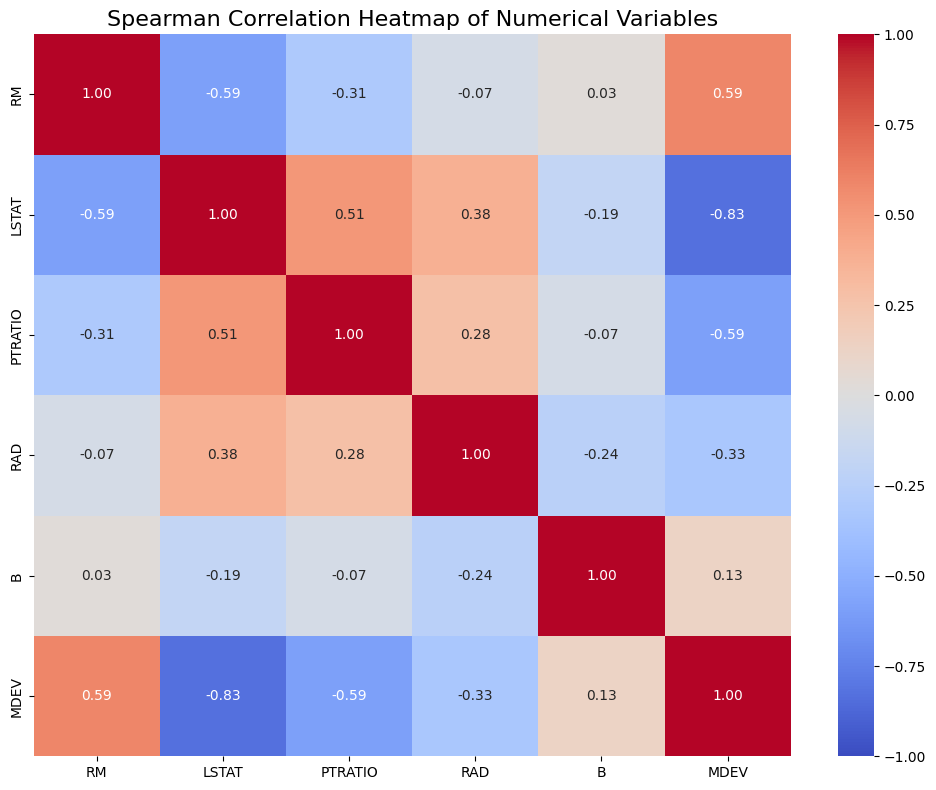

In [32]:
# Adiciona a variável alvo ao dataframe
X_train_filtered_2.loc[:, 'MDEV'] = y_train

# Calcula a matriz de correlação (Spearman)
corr_matrix = X_train_filtered_2.corr(method='spearman')

# Plota heatmap das correlações
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()


Como podemos observar a feature B apresenta a uma correlação muito baixa com a variável MDEV. Além disso, era originalmente usada como proxy de composição racial (dataset de 1978), hoje é considerado eticamente problemático. Portanto, optamos por removê-la do conjunto de variáveis restantes

In [33]:
X_train_filtered_3 = X_train_filtered_2.drop(columns=['MDEV','B'])
X_train_filtered_3

,RM,LSTAT,PTRATIO,RAD
0,6.114,14.98,20.2,24
1,6.642,9.69,16.4,5
2,5.304,24.91,20.2,24
3,5.856,13.00,18.6,3
4,6.083,12.79,19.6,5
...,...,...,...,...
339,5.951,17.92,16.4,5
340,7.267,6.05,17.6,4
341,6.153,13.15,17.8,3
342,5.990,14.67,21.0,4


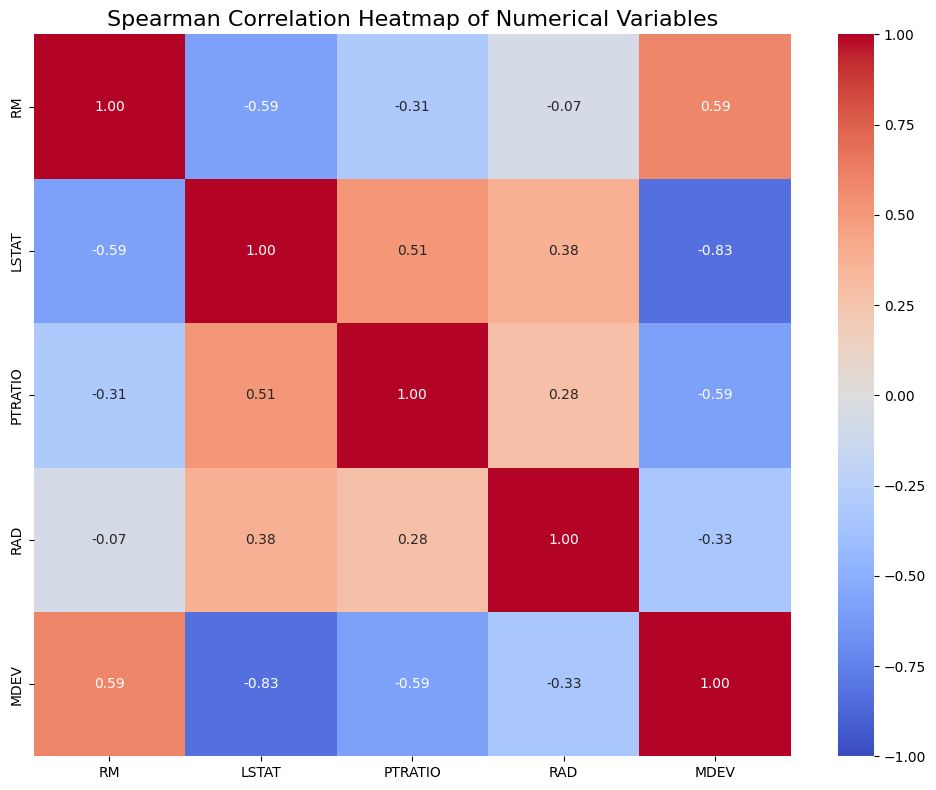

In [34]:
# Adiciona a variável alvo ao dataframe
X_train_filtered_3.loc[:, 'MDEV'] = y_train

# Calcula a matriz de correlação (Spearman)
corr_matrix = X_train_filtered_3.corr(method='spearman')

# Plota heatmap das correlações
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

In [35]:
round(X_train_filtered_3.describe(),2)

,RM,LSTAT,PTRATIO,RAD,MDEV
count,344.00,327.00,344.00,344.00,344.00
mean,6.26,12.45,18.68,9.31,21.90
std,0.60,6.52,1.90,8.49,7.74
min,3.56,1.73,13.00,1.00,5.60
25%,5.92,7.16,17.60,4.00,17.40
50%,6.21,11.64,19.10,5.00,21.30
75%,6.58,16.66,20.20,8.00,24.72
max,8.72,34.77,21.20,24.00,50.00


### Tratando os valores nulos da variável LSTAT

Dada a baixa quantidade de valores nulos (**17**) na variável ser pequena optamos por, inputa-los com a mediana. 

In [36]:
# Remove a coluna 'MDEV' (variável alvo) do dataframe
X_train_filtered_3 = X_train_filtered_3.drop(columns=['MDEV'])

# Substitui valores nulos pela mediana de cada coluna
X_train_null_free = X_train_filtered_3.fillna(X_train_filtered_3.median())

# Exibe o dataframe resultante sem nulos
X_train_null_free


,RM,LSTAT,PTRATIO,RAD
0,6.114,14.98,20.2,24
1,6.642,9.69,16.4,5
2,5.304,24.91,20.2,24
3,5.856,13.00,18.6,3
4,6.083,12.79,19.6,5
...,...,...,...,...
339,5.951,17.92,16.4,5
340,7.267,6.05,17.6,4
341,6.153,13.15,17.8,3
342,5.990,14.67,21.0,4


### Feature Engineering

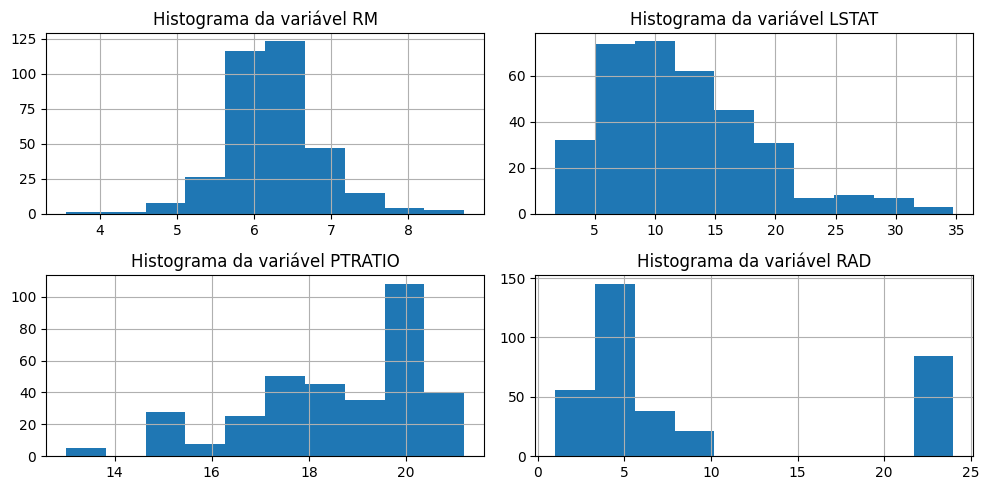

In [37]:
# Cria uma grade de subplots: 1 coluna e uma linha para cada variável
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

# Plota um histograma por variável
for col, ax in zip(X_train_null_free.columns, axs.flatten()):
    X_train_null_free[col].hist(bins=10, ax=ax)
    ax.set_title(f'Histograma da variável {col}')

# Ajusta layout para não sobrepor títulos
plt.tight_layout()


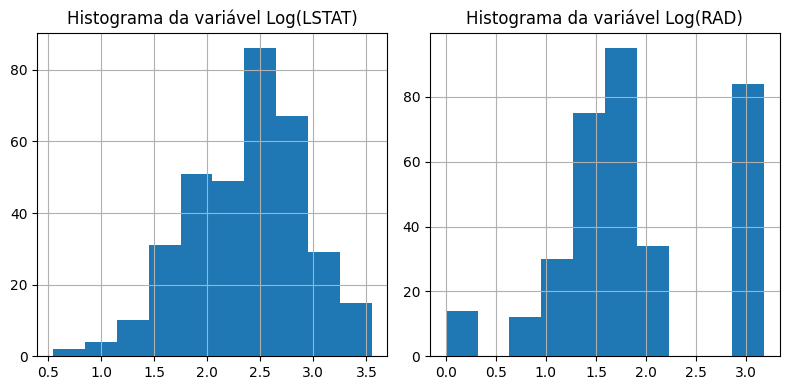

In [38]:
# Cria uma grade de subplots: 1 coluna e uma linha para cada variável
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# Plota um histograma por variável
for col, ax in zip(['LSTAT','RAD'], axs.flatten()):
    np.log(X_train_null_free[col]).hist(bins=10, ax=ax)
    ax.set_title(f'Histograma da variável Log({col})')

# Ajusta layout para não sobrepor títulos
plt.tight_layout()


In [39]:
# Classe customizada: aplica log às features selecionadas
class LogTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return np.log(X)
    def get_feature_names_out(self, input_features=None):
        return [f"{f}" for f in input_features]

# ColumnTransformer: aplica log só em 'LSTAT' e 'RAD'
preprocessor = ColumnTransformer(
    transformers=[
        ('lstat', Pipeline([
            ('log', LogTransformer())
        ]), ['LSTAT']),
        ('log', LogTransformer(), ['RAD'])
    ],
    remainder='passthrough',             # mantém as demais colunas
    verbose_feature_names_out=False
)

# Pipeline: imputação → pré-processamento → features polinomiais
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ('min_max', MinMaxScaler())
])

# Configura pipeline para retornar DataFrame em vez de array numpy
pipe.set_output(transform='pandas')

# Aplica pipeline nos dados de treino
X_train_transformed = pipe.fit_transform(X_train_null_free)

# Junta variável alvo de volta ao DataFrame transformado
df_train_transformed = X_train_transformed.copy()
df_train_transformed.loc[:, 'MEDV'] = y_train 

# Salva pipeline treinada em arquivo .pkl
joblib.dump(pipe, "./Utils/pipeline_tratamento.pkl")

# Salva nomes das colunas originais em um arquivo txt
with open("./Data/X_train_columns.txt", "w") as f:
    for col in X_train_null_free.columns:
        f.write(col + "\n")
